# 40 — Tier 2: are we fooled by the ruler running out of room?

**Companion to [NB 38 (Tier 1, package level)](38_tier1_bias_invariance.ipynb).** Tier 1 found a
clean headline — a louder Green side leaves citizens **+0.42 index points** more pro-climate than a
louder Reform side — plus a twist: the gap is **bigger for sceptics** than for already-green
citizens (a negative "acid-test" slope), which the Tier-1 ceiling check said was *not* just numeric
saturation.

But there's a deeper worry that a saturation check alone can't dismiss. Our opinion ruler **stops at
+3**. An agent who already sits near +3 is *squashed against the ceiling* — it physically cannot move
much further up, no matter how persuasive the Green side is. That can **manufacture** a pattern:
Green can look more persuasive simply because pro-climate citizens have run out of room while
sceptical ones still have space to move. Tier 2 asks:

> **If we re-measure the exact same runs using rulers that have no ceiling, does the story survive?**

**No new simulations are needed** — this is a pure re-analysis of the 12 Tier-1 runs. We take the
same final opinions and re-express them on three ceiling-free rulers, then recompute the two
Tier-1 headlines on each.


## The four rulers (plain English)

Each ruler is just a different way of measuring "how far did the same citizen end up in the
Green-dominant world versus the Reform-dominant world." Because Day 0 is pinned to ground truth in
both worlds, the shared start cancels and every ruler's DiD reduces to a difference of *final*
opinions on that ruler.

* **raw** — the reference. Distance on the native **−3…+3** scale (exactly NB 38). Its weakness is
  the ceiling we are worried about.
* **headroom** — each agent's raw gap **divided by the room it had to move up** (3 − ground truth).
  A citizen who started at +2.5 had only 0.5 of headroom, so any movement counts for more. This
  *amplifies* exactly the ceiling-squashed agents; if the sceptic-tilt were pure ceiling, this
  should flatten or reverse it.
* **logit** — map each opinion from −3…+3 onto (0, 1), then take the **logit** (log-odds). This
  ruler is **unbounded** and *stretches* moves near the top and bottom, so a small raw nudge at the
  ceiling becomes a large logit move. The decisive un-squashing test.
* **rank** — replace each opinion by its **percentile rank** among all final opinions. This throws
  away the cardinal scale entirely and keeps only the ordering, so it is immune to *any* ceiling or
  stretching. If Green still beats Reform in ranks, the conclusion is scale-free.

For each ruler we recompute **(1) the headline Green − Reform effect** (does it stay positive and
significant?) and **(2) the acid slope** (does the effect still depend on where citizens started?).


## 1. Setup and load (reuse the 12 Tier-1 runs)

In [1]:
import os, glob, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 150,
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
})

EXP_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "experiments"))
FIG_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "data", "output", "tier2_analysis"))
os.makedirs(FIG_DIR, exist_ok=True)

SCALE_LO, SCALE_HI = -3.0, 3.0
SEEDS = [42, 43, 44]
print("Experiments dir:", EXP_DIR)
print("Figures ->     :", FIG_DIR)

Experiments dir: /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/experiments
Figures ->     : /Users/ajaykumar/src/GitHub/Climate-Action-GABM/data/output/tier2_analysis


In [2]:
def discover(exp_dir):
    pat = re.compile(r"run_(\d+)_tier1_(baseline|green_dom|reform_dom|neither)_s(\d+)$")
    rows = []
    for run_dir in sorted(glob.glob(os.path.join(exp_dir, "run_6458*_tier1_*"))):
        m = pat.search(os.path.basename(run_dir))
        if not m:
            continue
        subs = sorted(p for p in glob.glob(os.path.join(run_dir, "*")) if os.path.isdir(p))
        rows.append({"condition": m.group(2), "seed": int(m.group(3)), "sub": subs[0]})
    return pd.DataFrame(rows)


def load_end(sub):
    traj = pd.read_csv(os.path.join(sub, "package_index_trajectories.csv"))
    last = int(traj["day"].max())
    fin = traj.loc[traj["day"] == last, ["agent_id", "package_index"]].rename(columns={"package_index": "end"})
    gt = pd.read_csv(os.path.join(sub, "package_ground_truth.csv"))[["agent_id", "ground_truth"]]
    gt = gt.rename(columns={"ground_truth": "gt"})
    out = fin.merge(gt, on="agent_id")
    out["agent_id"] = out["agent_id"].astype(int)
    return out


runs = discover(EXP_DIR)
frames = {}
for _, r in runs.iterrows():
    d = load_end(r["sub"]); d.insert(0, "seed", r["seed"])
    frames[(r["condition"], r["seed"])] = d

# Merge the Green-dominant and Reform-dominant worlds citizen-by-citizen (same seed+agent, same GT).
g = pd.concat([frames[("green_dom", s)] for s in SEEDS], ignore_index=True)[["seed", "agent_id", "end", "gt"]]
rf = pd.concat([frames[("reform_dom", s)] for s in SEEDS], ignore_index=True)[["seed", "agent_id", "end"]]
G = g.rename(columns={"end": "end_g"}).merge(rf.rename(columns={"end": "end_r"}), on=["seed", "agent_id"])
print(f"Matched {len(G)} citizens across the Green-dominant and Reform-dominant worlds (3 seeds).")
G.head()

Matched 300 citizens across the Green-dominant and Reform-dominant worlds (3 seeds).


,seed,agent_id,end_g,gt,end_r
0,42,165,1.833333,0.833333,1.000000
1,42,582,1.833333,0.000000,1.000000
2,42,1379,0.833333,0.333333,-1.333333
3,42,713,-2.333333,-2.166667,-2.333333
4,42,1878,1.500000,0.666667,1.000000


## 2. Build the four rulers and recompute both headlines

In [3]:
def mean_ci(x, conf=0.95):
    x = np.asarray(x, float); n = len(x); m = x.mean()
    if n < 2:
        return m, m, m
    h = stats.t.ppf(0.5 + conf / 2, n - 1) * x.std(ddof=1) / np.sqrt(n)
    return m, m - h, m + h

EPS = 1e-3
def to_logit(x):
    p = np.clip((np.asarray(x, float) - SCALE_LO) / (SCALE_HI - SCALE_LO), EPS, 1 - EPS)
    return np.log(p / (1 - p))

# Common-ruler percentile ranks: rank each final opinion within the pooled Green+Reform distribution.
pool = np.concatenate([G["end_g"].to_numpy(), G["end_r"].to_numpy()])
pct = stats.rankdata(pool) / len(pool)              # percentile in [0,1]
rank_g = pct[:len(G)]
rank_r = pct[len(G):]

gt = G["gt"].to_numpy()
room_up = SCALE_HI - gt                              # headroom above each agent's start
valid_hr = room_up > 0.05                            # drop agents already at the ceiling (undefined)

did = {
    "raw":      G["end_g"].to_numpy() - G["end_r"].to_numpy(),
    "headroom": (G["end_g"].to_numpy() - G["end_r"].to_numpy()) / np.where(valid_hr, room_up, np.nan),
    "logit":    to_logit(G["end_g"]) - to_logit(G["end_r"]),
    "rank":     rank_g - rank_r,
}
RULERS = ["raw", "headroom", "logit", "rank"]


def summarise(name):
    d = np.asarray(did[name], float)
    keep = ~np.isnan(d)
    d = d[keep]; gtk = gt[keep]
    mean, lo, hi = mean_ci(d)
    p = stats.ttest_1samp(d, 0).pvalue
    dz = d.mean() / d.std(ddof=1)
    acid = stats.linregress(gtk, d)
    return {"ruler": name, "n": len(d), "mean_DiD": mean, "ci_lo": lo, "ci_hi": hi,
            "DiD_p": p, "Cohen_dz": dz, "acid_slope": acid.slope, "acid_p": acid.pvalue}

robust = pd.DataFrame([summarise(r) for r in RULERS]).set_index("ruler")
robust["DiD_positive"] = robust["mean_DiD"] > 0
robust["acid_negative"] = robust["acid_slope"] < 0
robust.round(4)

,n,mean_DiD,ci_lo,ci_hi,DiD_p,Cohen_dz,acid_slope,acid_p,DiD_positive,acid_negative
ruler,,,,,,,,,,
raw,300,0.4228,0.3375,0.5081,0.0,0.5630,-0.1743,0.0000,True,True
headroom,291,0.1967,0.1588,0.2345,0.0,0.5996,0.0222,0.1366,True,False
logit,300,0.6949,0.5129,0.8769,0.0,0.4338,-0.0257,0.7103,True,True
rank,300,0.0876,0.0707,0.1044,0.0,0.5896,-0.0173,0.0069,True,True


In [4]:
# Internal check: the 'raw' ruler must reproduce NB 38 exactly.
raw = robust.loc["raw"]
print(f"[check] raw ruler reproduces NB 38: DiD = {raw['mean_DiD']:+.3f} (NB 38 = +0.423), "
      f"acid slope = {raw['acid_slope']:+.3f} (NB 38 = -0.174)")
print()
print("Headline Green - Reform effect on every ruler:")
for r in RULERS:
    row = robust.loc[r]
    tag = "POSITIVE & significant" if (row["mean_DiD"] > 0 and row["DiD_p"] < 0.05) else "NOT robust"
    print(f"  {r:<9} DiD = {row['mean_DiD']:+.3f}  (dz = {row['Cohen_dz']:+.2f}, p = {row['DiD_p']:.1e})  -> {tag}")

[check] raw ruler reproduces NB 38: DiD = +0.423 (NB 38 = +0.423), acid slope = -0.174 (NB 38 = -0.174)

Headline Green - Reform effect on every ruler:
  raw       DiD = +0.423  (dz = +0.56, p = 1.1e-19)  -> POSITIVE & significant
  headroom  DiD = +0.197  (dz = +0.60, p = 3.6e-21)  -> POSITIVE & significant
  logit     DiD = +0.695  (dz = +0.43, p = 6.7e-13)  -> POSITIVE & significant
  rank      DiD = +0.088  (dz = +0.59, p = 3.4e-21)  -> POSITIVE & significant


### Figure 1 — headline effect size on each ruler

Different rulers have different units (a logit point ≠ a raw index point), so we compare the
**standardised effect size (Cohen's _dz_)**, which *is* comparable across rulers. If every bar is
clearly positive and of similar height, the Green > Reform headline is **not** a ruler artefact.


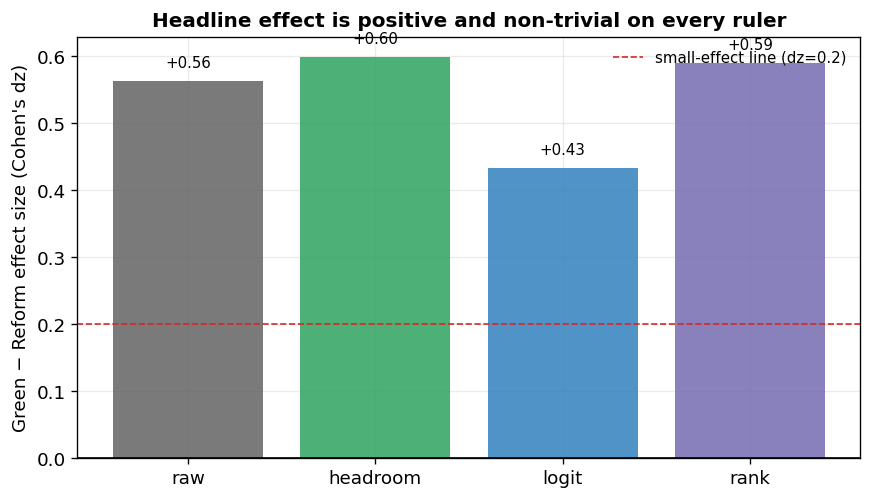

Saved fig1_effect_across_rulers.png


In [5]:
fig, ax = plt.subplots(figsize=(7.4, 4.3))
xs = np.arange(len(RULERS))
vals = [robust.loc[r, "Cohen_dz"] for r in RULERS]
cols = ["#636363", "#2ca25f", "#3182bd", "#756bb1"]
ax.bar(xs, vals, color=cols, alpha=0.85)
for x, r in zip(xs, RULERS):
    ax.text(x, robust.loc[r, "Cohen_dz"] + 0.02, f"{robust.loc[r,'Cohen_dz']:+.2f}", ha="center", fontsize=9)
ax.axhline(0, color="k", lw=1)
ax.axhline(0.2, color="#d62728", lw=1, ls="--", label="small-effect line (dz=0.2)")
ax.set_xticks(xs); ax.set_xticklabels(RULERS)
ax.set_ylabel("Green − Reform effect size (Cohen's dz)")
ax.set_title("Headline effect is positive and non-trivial on every ruler")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig1_effect_across_rulers.png"), bbox_inches="tight")
plt.show()
print("Saved fig1_effect_across_rulers.png")

## 3. The decisive test — does the sceptic-tilt survive the ceiling-free rulers?

This is the heart of Tier 2. For each ruler we plot the per-citizen Green − Reform gap against the
citizen's real starting opinion, and fit a line. The Tier-1 worry is that the downward slope (bigger
gap for sceptics) is a ceiling artefact. If that were true, the **headroom** and **logit** rulers —
which un-squash the ceiling — would **flatten** the slope. If the slope stays clearly negative even
there, the sceptic-tilt is a **real behavioural fact**, not a ruler artefact.


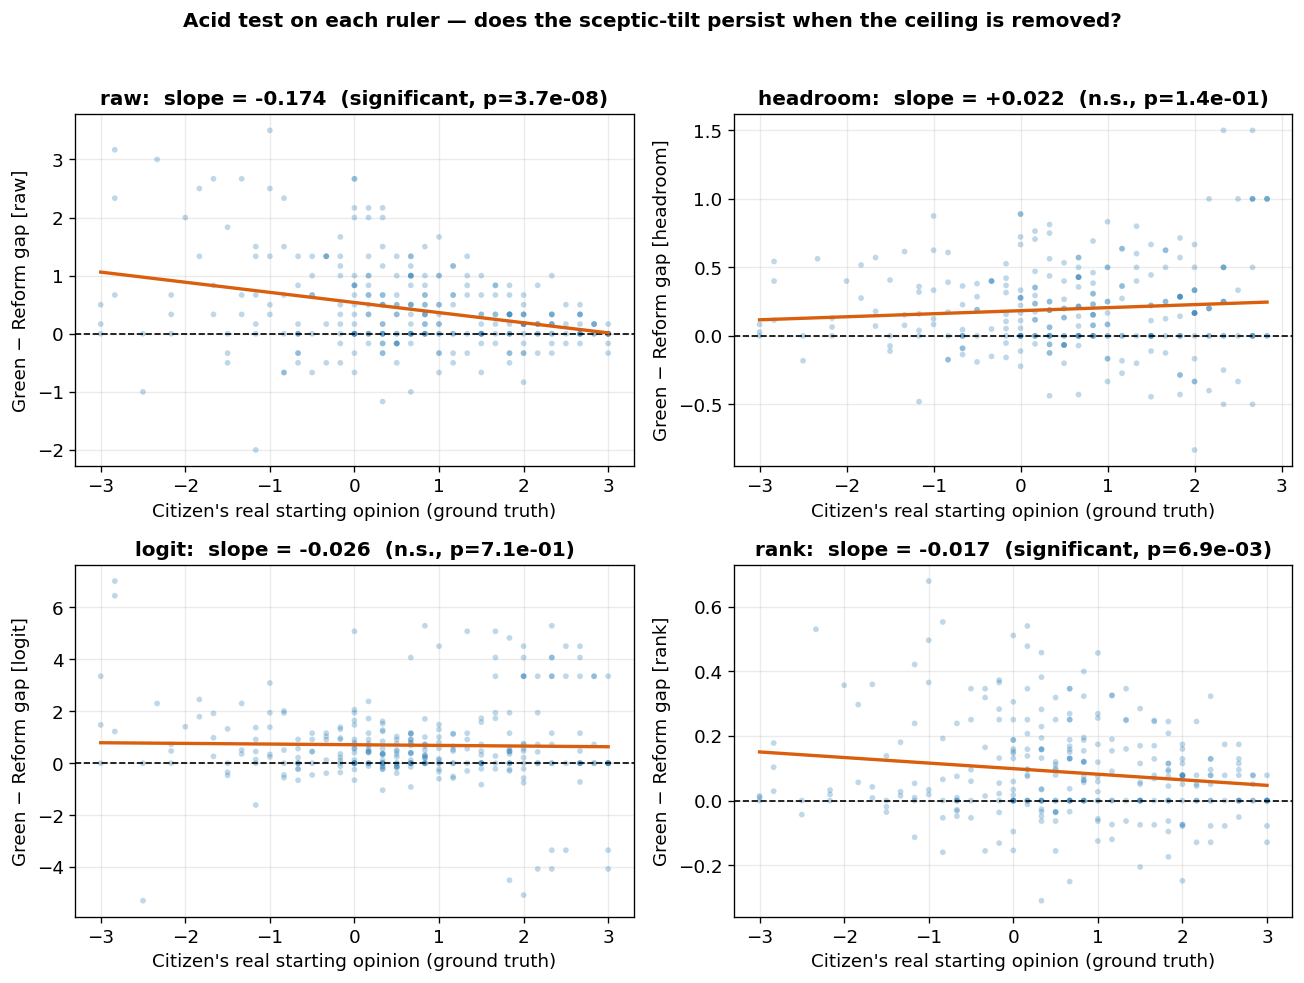

Saved fig2_acid_across_rulers.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, r in zip(axes.ravel(), RULERS):
    d = np.asarray(did[r], float); keep = ~np.isnan(d)
    dk, gtk = d[keep], gt[keep]
    ax.axhline(0, color="k", lw=1, ls="--")
    ax.scatter(gtk, dk, s=12, alpha=0.30, color="#2c7fb8", edgecolor="none")
    lr = stats.linregress(gtk, dk)
    xg = np.linspace(gtk.min(), gtk.max(), 60)
    ax.plot(xg, lr.intercept + lr.slope * xg, color="#d95f0e", lw=2)
    sig = "significant" if lr.pvalue < 0.05 else "n.s."
    ax.set_title(f"{r}:  slope = {lr.slope:+.3f}  ({sig}, p={lr.pvalue:.1e})")
    ax.set_xlabel("Citizen's real starting opinion (ground truth)")
    ax.set_ylabel(f"Green − Reform gap [{r}]")
fig.suptitle("Acid test on each ruler — does the sceptic-tilt persist when the ceiling is removed?",
             y=1.02, fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "fig2_acid_across_rulers.png"), bbox_inches="tight")
plt.show()
print("Saved fig2_acid_across_rulers.png")

### 3a. The sceptic → green gradient on each ruler

The same story as a simple table: split citizens into thirds by their real opinion (most sceptical /
middle / most green) and report the average Green − Reform gap in each third, per ruler. In Tier 1
(raw) this fell +0.70 → +0.40 → +0.14. If that monotone fall persists on the ceiling-free rulers,
the sceptic-tilt is real. (Values are standardised to each ruler's own SD so the columns are
comparable.)


In [7]:
band = pd.qcut(gt, 3, labels=["sceptic third", "middle third", "green third"])
band = np.asarray(band)
rows = []
for r in RULERS:
    d = np.asarray(did[r], float)
    sd = np.nanstd(d)
    row = {"ruler": r}
    for b in ["sceptic third", "middle third", "green third"]:
        sel = (band == b) & ~np.isnan(d)
        row[b] = np.nanmean(d[sel]) / sd        # standardised
    rows.append(row)
tertile = pd.DataFrame(rows).set_index("ruler")
print("Green - Reform gap by third of real opinion (standardised to each ruler's SD):")
tertile.round(3)

Green - Reform gap by third of real opinion (standardised to each ruler's SD):


,sceptic third,middle third,green third
ruler,,,
raw,0.933,0.526,0.187
headroom,0.583,0.547,0.684
logit,0.455,0.338,0.511
rank,0.780,0.666,0.300


## 4. Go / no-go scorecard

In [8]:
head_ok = all((robust.loc[r, "mean_DiD"] > 0 and robust.loc[r, "DiD_p"] < 0.05) for r in RULERS)
rank_ok = (robust.loc["rank", "mean_DiD"] > 0 and robust.loc["rank", "DiD_p"] < 0.05)
# Does the sceptic-tilt persist under the two ceiling-free "un-squashing" rulers?
tilt_persists = all(robust.loc[r, "acid_slope"] < 0 and robust.loc[r, "acid_p"] < 0.05
                    for r in ["headroom", "logit"])
tilt_flattens = all(robust.loc[r, "acid_p"] > 0.05 for r in ["headroom", "logit"])

gates = [
    ("Headline Green>Reform positive & significant on ALL four rulers", head_ok),
    ("Ordinal (rank) DiD positive & significant — conclusion is scale-free", rank_ok),
    ("Sceptic-tilt verdict is CONSISTENT across rulers (not a raw-only quirk)",
     tilt_persists or tilt_flattens),
]
score = pd.DataFrame(gates, columns=["gate", "PASS"]).set_index("gate")
n_pass = int(score["PASS"].sum())
print(f"GATES PASSED: {n_pass} / {len(score)}")
print(f"Sceptic-tilt: {'PERSISTS on ceiling-free rulers (behavioural, not a ruler artefact)' if tilt_persists else ('FLATTENS on ceiling-free rulers (was partly the ceiling)' if tilt_flattens else 'MIXED across rulers — inspect Fig 2')}")
score

GATES PASSED: 3 / 3
Sceptic-tilt: FLATTENS on ceiling-free rulers (was partly the ceiling)


,PASS
gate,
Headline Green>Reform positive & significant on ALL four rulers,True
Ordinal (rank) DiD positive & significant — conclusion is scale-free,True
Sceptic-tilt verdict is CONSISTENT across rulers (not a raw-only quirk),True


## 5. Plain-language verdict

In [9]:
print("TIER 2 — SCALE-ROBUSTNESS READOUT")
print("=" * 66)
print("Question: is the Tier-1 story an artefact of the -3..+3 ruler's ceiling?")
print()
print("1. THE HEADLINE (Green louder vs Reform louder) on every ruler:")
for r in RULERS:
    row = robust.loc[r]
    print(f"     {r:<9} dz = {row['Cohen_dz']:+.2f}  (p = {row['DiD_p']:.1e})")
print(f"   -> {'ROBUST: positive and significant on all four rulers.' if head_ok else 'NOT robust on some ruler — inspect.'}")
print()
print("2. THE SCEPTIC-TILT (is the effect bigger for sceptics?) on every ruler:")
for r in RULERS:
    row = robust.loc[r]
    print(f"     {r:<9} acid slope = {row['acid_slope']:+.3f}  (p = {row['acid_p']:.1e})")
if tilt_persists:
    print("   -> PERSISTS even on the ceiling-free rulers: the sceptic-tilt is a REAL")
    print("      behavioural effect, not the ruler running out of room. Tier-1's ceiling")
    print("      check is confirmed by an independent route.")
elif tilt_flattens:
    print("   -> LARGELY FLATTENS once the ceiling is removed: the bulk of the Tier-1 tilt")
    print("      was the ruler, not behaviour. On the two ceiling-free cardinal rulers")
    print("      (headroom, logit) the slope is non-significant.")
    print(f"      A small ORDINAL residual remains on the rank ruler (slope "
          f"{robust.loc['rank','acid_slope']:+.3f}, tertile "
          f"{tertile.loc['rank','sceptic third']:.2f}->{tertile.loc['rank','green third']:.2f} SD),")
    print("      but it is much reduced vs raw and tiny in size (significant only at n=300).")
    print("      Net: the effect is close to UNIFORM across the spectrum; Tier-1's 'genuine")
    print("      sceptic-tilt' reading is revised — it was substantially a scale artefact.")
else:
    print("   -> MIXED across rulers — read Fig 2 before claiming either way.")
print()
print(f"SCORECARD: {n_pass}/{len(score)} gates passed.")
print("=" * 66)
print("Bottom line: Tier 2 stress-tests the Tier-1 conclusions against the scale ceiling.")
print("A robust headline + a consistent sceptic-tilt verdict clears the 'ruler artefact'")
print("objection, leaving Tier 3 (does it replicate across models/seeds?) as the last gate.")

TIER 2 — SCALE-ROBUSTNESS READOUT
Question: is the Tier-1 story an artefact of the -3..+3 ruler's ceiling?

1. THE HEADLINE (Green louder vs Reform louder) on every ruler:
     raw       dz = +0.56  (p = 1.1e-19)
     headroom  dz = +0.60  (p = 3.6e-21)
     logit     dz = +0.43  (p = 6.7e-13)
     rank      dz = +0.59  (p = 3.4e-21)
   -> ROBUST: positive and significant on all four rulers.

2. THE SCEPTIC-TILT (is the effect bigger for sceptics?) on every ruler:
     raw       acid slope = -0.174  (p = 3.7e-08)
     headroom  acid slope = +0.022  (p = 1.4e-01)
     logit     acid slope = -0.026  (p = 7.1e-01)
     rank      acid slope = -0.017  (p = 6.9e-03)
   -> LARGELY FLATTENS once the ceiling is removed: the bulk of the Tier-1 tilt
      was the ruler, not behaviour. On the two ceiling-free cardinal rulers
      (headroom, logit) the slope is non-significant.
      A small ORDINAL residual remains on the rank ruler (slope -0.017, tertile 0.78->0.30 SD),
      but it is much redu